In [1]:
import matplotlib.pyplot as plt
from glob import glob
import matplotlib.patches as mpatches
# import cosima_cookbook as cc
import numpy as np
from matplotlib.gridspec import GridSpec
import matplotlib.ticker as mticker
import cmocean.cm as cm
import xarray as xr
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cft
import gc
from scipy.interpolate import griddata
from matplotlib import ticker
import scipy.io as sio
# import seawater as sw
import seaborn as sns
import matplotlib.patheffects as pe
from scipy import stats
import matplotlib.patheffects as mpe
from tqdm import tqdm

In [2]:
# Set figures properties
# sns.set_style('whitegrid')
# sns.reset_orig()
plt.rcParams['font.size'] = 12
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.titleweight'] = 'bold'

In [3]:
def argnear(dat,val,how_many=1):
    dif = np.abs(dat-val)
    idx = np.argsort(dif)
    return idx[:how_many]

In [5]:
path_bathy = '/g/data/ik11/inputs/GEBCO_2022/GEBCO_2022.nc'
bathy = -1*xr.open_dataset(path_bathy).elevation.sel(lon = slice(19, 66), lat = slice(-50,-35)).load()

## Frontal position

In [6]:
path = '/g/data/v45/fs3401/AmelieMeyer_Agulhas_meander/data/'
data_meander   = glob(path + 'altimetry_meander_location_daily_1993_2019_3m_30thrs.mat')
# data_bathy      = glob(path + 'GMRTv3_7_20200805topo_standing_meander.grd')
lon_boundaries = glob(path + 'meander_regions_lat_lon.mat')

meander_var = sio.loadmat(data_meander[0])
lon_front  = meander_var['meand_lon'][:,0]
lat_front = meander_var['meand_loc_lat'].T
lat_front_mean = np.nanmean(lat_front, axis = 0)
lat_front_1stDecade = np.nanmean(lat_front[:12*10], axis = 0)
# lat_front_2ndDecade = np.nanmean(lat_front[12*10:12*20], axis = 0)
lat_front_2ndDecade = np.nanmean(lat_front[-12*10:], axis = 0)
###################################################################
front_boundary = argnear(lon_front, 67.5)[0]
lon_front      = lon_front[:front_boundary]
lat_front_mean = lat_front_mean[:front_boundary]

/jobfs/173906483.gadi-pbs/ipykernel_3894724/223377973.py:9: RuntimeWarning: Mean of empty slice
  lat_front_mean = np.nanmean(lat_front, axis = 0)
/jobfs/173906483.gadi-pbs/ipykernel_3894724/223377973.py:10: RuntimeWarning: Mean of empty slice
  lat_front_1stDecade = np.nanmean(lat_front[:12*10], axis = 0)
/jobfs/173906483.gadi-pbs/ipykernel_3894724/223377973.py:12: RuntimeWarning: Mean of empty slice
  lat_front_2ndDecade = np.nanmean(lat_front[-12*10:], axis = 0)


In [7]:
# time      = meander_var['meand_time'][0]
# from datetime import datetime
# from datetime import timedelta
# # import pandas as pd

# time_diff = np.cumsum(np.append(0, time[1:]-time[:-1]))
# dates = np.array([])
# for t in range(len(time)):
#     dates = np.append(dates, datetime(1993,1,15) + timedelta(days=int(time_diff[t])))

## Loading SLA trend

In [8]:
path_load = '/g/data/v45/fs3401/AmelieMeyer_Agulhas_meander/scripts/trends/output/'
ds = xr.open_dataset(path_load + 'SLA_trend_26years.nc')

slope_decade_SLA = ds.slope_decade_SLA.load()
p_value_SLA = ds.p_value_SLA.load()
Ln, Lt = ds.longitude, ds.latitude

## Loading SST

In [9]:
SST_data  = xr.open_dataset(path_load+'SST_trend_26years.nc')
SST_trend = SST_data.slope_decade_SST.load()
p_value_SST = SST_data.p_value_SST.load()
SST_lon, SST_lat = SST_data.longitude, SST_data.latitude

In [10]:
lat_crest_1, lon_crest_1   = -40.5, 25.3
lat_crest_2, lon_crest_2   = -40.4, 31
lat_crest_4, lon_crest_4   = -41.5, 52.3
lat_crest_7, lon_crest_7   = -44.3, 62.3
############### TROUGHS
lat_trough_1, lon_trough_1 = -38.2, 27.8
lat_trough_2, lon_trough_2 = -37.7, 32.3
lat_trough_3, lon_trough_3 = -39.5, 38
lat_trough_4, lon_trough_4 = -39.5, 50

## Figures

In [11]:
path_fig = '/g/data/jk72/fs3401/Desktop/Agulhas_meander/figures/'
props = dict(boxstyle='round', facecolor='w')
grd = GridSpec(100,100)

extent = [19.99, 65.01, -47, -30.5]
props = dict(boxstyle='round', facecolor='w', alpha=1)
outline = mpe.withStroke(linewidth=2, foreground='w')
ft, color_ = 8, 'w'

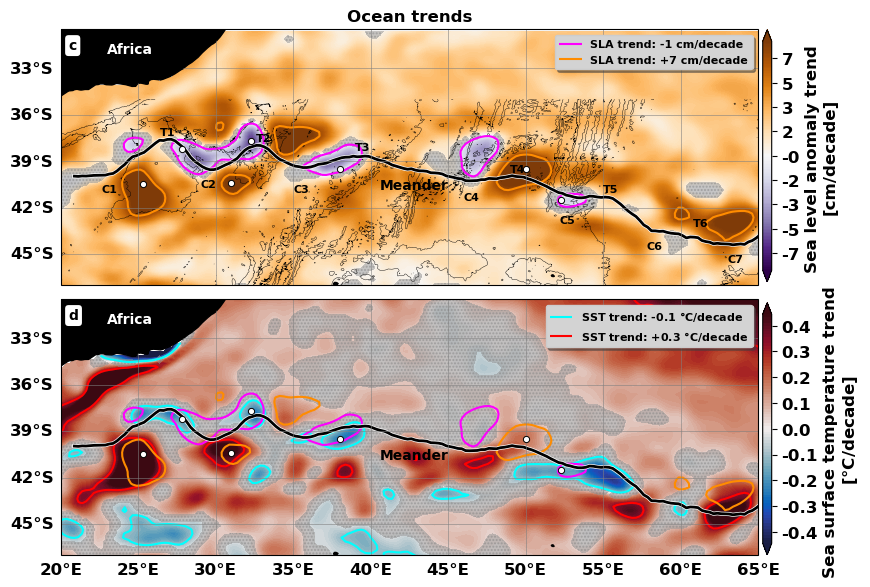

In [15]:
fig = plt.figure(figsize = (9,7))

####################### FIGURE 1
ax = [fig.add_subplot(grd[:50,:], projection=ccrs.PlateCarree()),
      fig.add_subplot(grd[50:,:], projection=ccrs.PlateCarree()),]

ax[0].contour(bathy.lon, bathy.lat, bathy, levels=np.arange(0,8000,2000), colors='k', linewidths=.3)
cf1 = ax[0].contourf(Ln, Lt, slope_decade_SLA*1e2, np.arange(-8, 8.1, .1), cmap = 'PuOr_r', extend='both')
cf_hatch = ax[0].contourf(Ln, Lt, p_value_SLA, [0.05,1], cmap='Greys',alpha=.5, hatches=['.....']) 
cf_hatch.set_edgecolor('grey')
cf_hatch.set_linewidth(0)

cf2 = ax[1].contourf(SST_lon, SST_lat, SST_trend, np.arange(-.4,.41,.01), cmap = cm.balance, extend='both')
cf_hatch = ax[1].contourf(SST_lon, SST_lat, p_value_SST, [0.05,1], cmap='Greys',alpha=.5, hatches=['.....']) 
cf_hatch.set_edgecolor('grey')
cf_hatch.set_linewidth(0)

cr_SST = ax[1].contour(SST_lon, SST_lat, SST_trend, [-.1,.3], colors = ['cyan', 'red'], linestyles = 'solid')

####################################### Details
for i in range(len(ax)):
    cr_SLA = ax[i].contour(Ln, Lt, slope_decade_SLA*1e2, [-1,7], colors = ['magenta','darkorange'], linestyles = 'solid')

    ax[i].scatter(lon_crest_1, lat_crest_1, s = 20, color = 'w', edgecolor = 'k', zorder = 50, linewidth=.7)
    ax[i].scatter(lon_crest_2, lat_crest_2, s = 20, color = 'w', edgecolor = 'k', zorder = 50, linewidth=.7)
    ax[i].scatter(lon_crest_4, lat_crest_4, s = 20, color = 'w', edgecolor = 'k', zorder = 50, linewidth=.7)
    # ax[i].scatter(lon_crest_7, lat_crest_7, s = 20, color = 'w', edgecolor = 'k', zorder = 50, linewidth=.7)
    ax[i].scatter(lon_trough_1, lat_trough_1, s = 20, color = 'w', edgecolor = 'k', zorder = 50, linewidth=.7)
    ax[i].scatter(lon_trough_2, lat_trough_2, s = 20, color = 'w', edgecolor = 'k', zorder = 50, linewidth=.7)
    ax[i].scatter(lon_trough_3, lat_trough_3, s = 20, color = 'w', edgecolor = 'k', zorder = 50, linewidth=.7)
    ax[i].scatter(lon_trough_4, lat_trough_4, s = 20, color = 'w', edgecolor = 'k', zorder = 50, linewidth=.7)

    ax[i].plot(lon_front, lat_front_mean, color = 'w', linewidth = 3)
    ax[i].plot(lon_front, lat_front_mean, color = 'k', linewidth = 2)
    ax[i].annotate(text='Meander', color='k', xy=(40.6,-40.8), xycoords='data', fontsize = 10, zorder = 300, fontweight = 'bold')
    ax[i].annotate(text='Africa', color='w', xy=(23,-32), xycoords='data', fontsize = 10, zorder = 300)
    ax[i].set_extent(extent, ccrs.PlateCarree())
    ax[i].add_feature(cartopy.feature.COASTLINE)
    ax[i].add_feature(cartopy.feature.LAND, facecolor='k', zorder=10)
    gl = ax[i].gridlines(draw_labels = False, crs=ccrs.PlateCarree(), linewidth=0.4, color='grey')
    gl.left_labels = True
    gl.ylocator = mticker.FixedLocator(np.arange(-60, -30, 3))
    gl.xlocator = mticker.FixedLocator(np.arange(10, 80, 5))
    gl.ylabel_style = {'size': 12}
    if i == 1:
        gl.bottom_labels = True
        gl.xlabel_style = {'size': 12}

ax[0].set_title('Ocean trends', fontsize = 12)
ax[0].annotate(text='C1', color='k', xy=(22.6,-41), xycoords='data', fontsize = ft, zorder = 300)
ax[0].annotate(text='T1', color='k', xy=(26.4,-37.35), xycoords='data', fontsize = ft, zorder = 300)
ax[0].annotate(text='C2', color='k', xy=(29,-40.7), xycoords='data', fontsize = ft, zorder = 300)
ax[0].annotate(text='T2', color='k', xy=(32.6,-37.7), xycoords='data', fontsize = ft, zorder = 300)
ax[0].annotate(text='C3', color='k', xy=(35,-41), xycoords='data', fontsize = ft, zorder = 300)
ax[0].annotate(text='T3', color='k', xy=(39,-38.3), xycoords='data', fontsize = ft, zorder = 300)
ax[0].annotate(text='C4', color='k', xy=(46,-41.5), xycoords='data', fontsize = ft, zorder = 300)
ax[0].annotate(text='T4', color='k', xy=(49,-39.7), xycoords='data', fontsize = ft, zorder = 300)
ax[0].annotate(text='C5', color='k', xy=(52.2,-43), xycoords='data', fontsize = ft, zorder = 300)
ax[0].annotate(text='T5', color='k', xy=(55,-41), xycoords='data', fontsize = ft, zorder = 300)
ax[0].annotate(text='C6', color='k', xy=(57.8,-44.7), xycoords='data', fontsize = ft, zorder = 300)
ax[0].annotate(text='T6', color='k', xy=(60.8,-43.2), xycoords='data', fontsize = ft, zorder = 300)
ax[0].annotate(text='C7', color='k', xy=(63,-45.5), xycoords='data', fontsize = ft, zorder = 300)

handles_SLA, labels_SLA = cr_SLA.legend_elements()
handles_SST, labels_SST = cr_SST.legend_elements()
ax[0].legend(handles_SLA, 
             [r'SLA trend: -1 cm/decade', 'SLA trend: +7 cm/decade'],
             loc = 'upper right', fontsize = 8, facecolor = 'lightgrey', shadow=True)
ax[1].legend(handles_SST, 
             [r'SST trend: -0.1 $\degree$C/decade', 'SST trend: +0.3 $\degree$C/decade'],
             loc = 'upper right', fontsize = 8, facecolor = 'lightgrey', shadow=True)

ax[0].annotate(text='c', color='k', xy=(20.5,-31.8), xycoords='data', bbox=props, fontsize = 10, zorder = 300)
ax[1].annotate(text='d', color='k', xy=(20.5,-31.8), xycoords='data', bbox=props, fontsize = 10, zorder = 300)

## Colorbar
bar = plt.axes([0.905, 0.51, 0.01, 0.36])
cbar = plt.colorbar(cf1, cax = bar, format = '%.0f')  
cbar.set_label('Sea level anomaly trend \n' +  r'[cm/decade]') 

bar = plt.axes([0.905, 0.12, 0.01, 0.36])
cbar = plt.colorbar(cf2, cax = bar, format = '%.01f')  
cbar.set_label('Sea surface temperature trend \n' + r'[$\degree$C/decade]') 

plt.savefig(path_fig + 'Fig2.jpg', dpi =300, bbox_inches = 'tight')

In [18]:
178.8*220.4/263.5

149.55415559772297

  cf_hatch.collections[0].set_edgecolor('grey')

  cf_hatch.collections[0].set_linewidth(0)

  cf_hatch.collections[0].set_edgecolor('grey')

  cf_hatch.collections[0].set_linewidth(0)



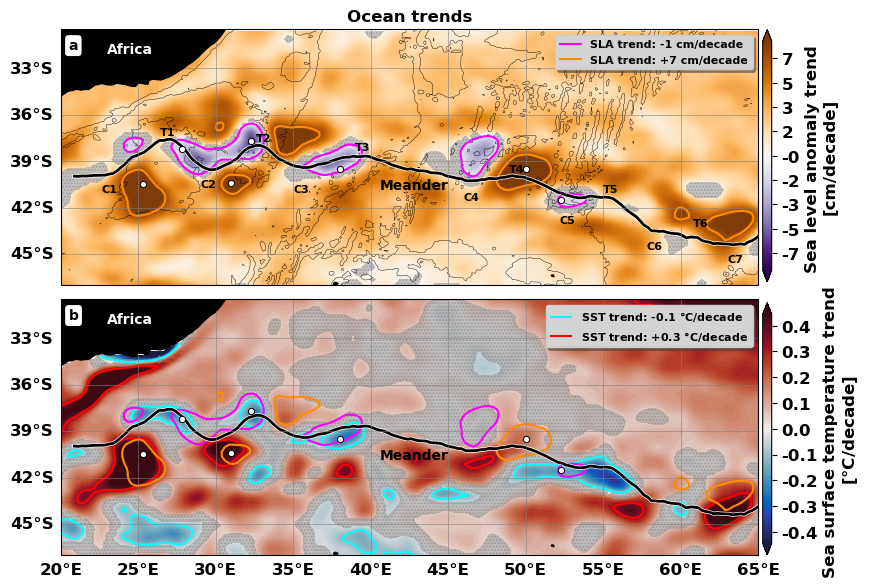

In [17]:
fig = plt.figure(figsize = (9,7))

####################### FIGURE 1
ax = [fig.add_subplot(grd[:50,:], projection=ccrs.PlateCarree()),
      fig.add_subplot(grd[50:,:], projection=ccrs.PlateCarree()),]
a
ax[0].contour(bathy.xt_ocean, bathy.yt_ocean, bathy, levels=np.arange(0,8000,2000), colors='k', linewidths=.3)
cf1 = ax[0].contourf(Ln, Lt, slope_decade_SLA*1e2, np.arange(-8, 8.1, .1), cmap = 'PuOr_r', extend='both')
cf_hatch = ax[0].contourf(Ln, Lt, p_value_SLA, [0.05,1], cmap='Greys',alpha=.5, hatches=['.....']) 
cf_hatch.collections[0].set_edgecolor('grey')
cf_hatch.collections[0].set_linewidth(0)

cf2 = ax[1].contourf(SST_lon, SST_lat, SST_trend, np.arange(-.4,.41,.01), cmap = cm.balance, extend='both')
cf_hatch = ax[1].contourf(SST_lon, SST_lat, p_value_SST, [0.05,1], cmap='Greys',alpha=.5, hatches=['.....']) 
cf_hatch.collections[0].set_edgecolor('grey')
cf_hatch.collections[0].set_linewidth(0)

cr_SST = ax[1].contour(SST_lon, SST_lat, SST_trend, [-.1,.3], colors = ['cyan', 'red'], linestyles = 'solid')

####################################### Details
for i in range(len(ax)):
    cr_SLA = ax[i].contour(Ln, Lt, slope_decade_SLA*1e2, [-1,7], colors = ['magenta','darkorange'], linestyles = 'solid')

    ax[i].scatter(lon_crest_1, lat_crest_1, s = 20, color = 'w', edgecolor = 'k', zorder = 50, linewidth=.7)
    ax[i].scatter(lon_crest_2, lat_crest_2, s = 20, color = 'w', edgecolor = 'k', zorder = 50, linewidth=.7)
    ax[i].scatter(lon_crest_4, lat_crest_4, s = 20, color = 'w', edgecolor = 'k', zorder = 50, linewidth=.7)
    # ax[i].scatter(lon_crest_7, lat_crest_7, s = 20, color = 'w', edgecolor = 'k', zorder = 50, linewidth=.7)
    ax[i].scatter(lon_trough_1, lat_trough_1, s = 20, color = 'w', edgecolor = 'k', zorder = 50, linewidth=.7)
    ax[i].scatter(lon_trough_2, lat_trough_2, s = 20, color = 'w', edgecolor = 'k', zorder = 50, linewidth=.7)
    ax[i].scatter(lon_trough_3, lat_trough_3, s = 20, color = 'w', edgecolor = 'k', zorder = 50, linewidth=.7)
    ax[i].scatter(lon_trough_4, lat_trough_4, s = 20, color = 'w', edgecolor = 'k', zorder = 50, linewidth=.7)

    ax[i].plot(lon_front, lat_front_mean, color = 'w', linewidth = 3)
    ax[i].plot(lon_front, lat_front_mean, color = 'k', linewidth = 2)
    ax[i].annotate(text='Meander', color='k', xy=(40.6,-40.8), xycoords='data', fontsize = 10, zorder = 300, fontweight = 'bold')
    ax[i].annotate(text='Africa', color='w', xy=(23,-32), xycoords='data', fontsize = 10, zorder = 300)
    ax[i].set_extent(extent, ccrs.PlateCarree())
    ax[i].add_feature(cartopy.feature.COASTLINE)
    ax[i].add_feature(cartopy.feature.LAND, facecolor='k', zorder=10)
    gl = ax[i].gridlines(draw_labels = False, crs=ccrs.PlateCarree(), linewidth=0.4, color='grey')
    gl.left_labels = True
    gl.ylocator = mticker.FixedLocator(np.arange(-60, -30, 3))
    gl.xlocator = mticker.FixedLocator(np.arange(10, 80, 5))
    gl.ylabel_style = {'size': 12}
    if i == 1:
        gl.bottom_labels = True
        gl.xlabel_style = {'size': 12}

ax[0].set_title('Ocean trends', fontsize = 12)
ax[0].annotate(text='C1', color='k', xy=(22.6,-41), xycoords='data', fontsize = ft, zorder = 300)
ax[0].annotate(text='T1', color='k', xy=(26.4,-37.35), xycoords='data', fontsize = ft, zorder = 300)
ax[0].annotate(text='C2', color='k', xy=(29,-40.7), xycoords='data', fontsize = ft, zorder = 300)
ax[0].annotate(text='T2', color='k', xy=(32.6,-37.7), xycoords='data', fontsize = ft, zorder = 300)
ax[0].annotate(text='C3', color='k', xy=(35,-41), xycoords='data', fontsize = ft, zorder = 300)
ax[0].annotate(text='T3', color='k', xy=(39,-38.3), xycoords='data', fontsize = ft, zorder = 300)
ax[0].annotate(text='C4', color='k', xy=(46,-41.5), xycoords='data', fontsize = ft, zorder = 300)
ax[0].annotate(text='T4', color='k', xy=(48.9,-39.7), xycoords='data', fontsize = ft, zorder = 300)
ax[0].annotate(text='C5', color='k', xy=(52.2,-43), xycoords='data', fontsize = ft, zorder = 300)
ax[0].annotate(text='T5', color='k', xy=(55,-41), xycoords='data', fontsize = ft, zorder = 300)
ax[0].annotate(text='C6', color='k', xy=(57.8,-44.7), xycoords='data', fontsize = ft, zorder = 300)
ax[0].annotate(text='T6', color='k', xy=(60.8,-43.2), xycoords='data', fontsize = ft, zorder = 300)
ax[0].annotate(text='C7', color='k', xy=(63,-45.5), xycoords='data', fontsize = ft, zorder = 300)

handles_SLA, labels_SLA = cr_SLA.legend_elements()
handles_SST, labels_SST = cr_SST.legend_elements()
ax[0].legend(handles_SLA, 
             [r'SLA trend: -1 cm/decade', 'SLA trend: +7 cm/decade'],
             loc = 'upper right', fontsize = 8, facecolor = 'lightgrey', shadow=True)
ax[1].legend(handles_SST, 
             [r'SST trend: -0.1 $\degree$C/decade', 'SST trend: +0.3 $\degree$C/decade'],
             loc = 'upper right', fontsize = 8, facecolor = 'lightgrey', shadow=True)

ax[0].annotate(text='a', color='k', xy=(20.5,-31.8), xycoords='data', bbox=props, fontsize = 10, zorder = 300)
ax[1].annotate(text='b', color='k', xy=(20.5,-31.8), xycoords='data', bbox=props, fontsize = 10, zorder = 300)

## Colorbar
bar = plt.axes([0.905, 0.51, 0.01, 0.36])
cbar = plt.colorbar(cf1, cax = bar, format = '%.0f')  
cbar.set_label('Sea level anomaly trend \n' +  r'[cm/decade]') 

bar = plt.axes([0.905, 0.12, 0.01, 0.36])
cbar = plt.colorbar(cf2, cax = bar, format = '%.01f')  
cbar.set_label('Sea surface temperature trend \n' + r'[$\degree$C/decade]') 

plt.savefig(path_fig + 'Fig2.jpg', dpi =300, bbox_inches = 'tight')

## Different hash

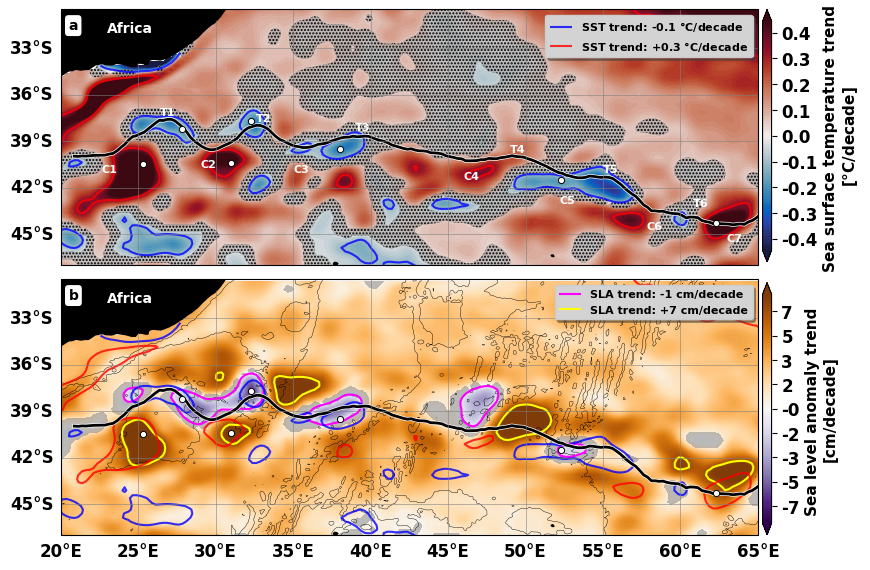

In [88]:
fig = plt.figure(figsize = (9,7))

####################### FIGURE 1
ax = [fig.add_subplot(grd[:50,:], projection=ccrs.PlateCarree()),
      fig.add_subplot(grd[50:,:], projection=ccrs.PlateCarree()),]

ax[1].contour(bathy.xt_ocean, bathy.yt_ocean, bathy, levels=np.arange(0,8000,2000), colors='k', linewidths=.3)
cf1 = ax[1].contourf(Ln, Lt, slope_decade_SLA*1e2, np.arange(-8, 8.1, .1), cmap = 'PuOr_r', extend='both')
ax[1].contourf(Ln, Lt, p_value_SLA, [0.05,1], cmap='gray', alpha = .5) 
cr_SLA = ax[1].contour(Ln, Lt, slope_decade_SLA*1e2, [-1,7], colors = ['magenta','yellow'], linestyles = 'solid')

cf2 = ax[0].contourf(SST_lon, SST_lat, SST_trend, np.arange(-.4,.41,.01), cmap = cm.balance, extend='both')
ax[0].contourf(SST_lon, SST_lat, p_value_SST, [0.05,1], cmap='Greys',alpha=.5, hatches=['.....']) 


####################################### Details
for i in range(len(ax)):
    cr_SST = ax[i].contour(SST_lon, SST_lat, SST_trend, [-.1,.3], colors = ['blue', 'red'], linestyles = 'solid', alpha=.8)

    ax[i].scatter(lon_crest_1, lat_crest_1, s = 20, color = 'w', edgecolor = 'k', zorder = 50, linewidth=.7)
    ax[i].scatter(lon_crest_2, lat_crest_2, s = 20, color = 'w', edgecolor = 'k', zorder = 50, linewidth=.7)
    ax[i].scatter(lon_crest_4, lat_crest_4, s = 20, color = 'w', edgecolor = 'k', zorder = 50, linewidth=.7)
    ax[i].scatter(lon_crest_7, lat_crest_7, s = 20, color = 'w', edgecolor = 'k', zorder = 50, linewidth=.7)
    ax[i].scatter(lon_trough_1, lat_trough_1, s = 20, color = 'w', edgecolor = 'k', zorder = 50, linewidth=.7)
    ax[i].scatter(lon_trough_2, lat_trough_2, s = 20, color = 'w', edgecolor = 'k', zorder = 50, linewidth=.7)
    ax[i].scatter(lon_trough_3, lat_trough_3, s = 20, color = 'w', edgecolor = 'k', zorder = 50, linewidth=.7)

    ax[i].plot(lon_front, lat_front_mean, color = 'w', linewidth = 3)
    ax[i].plot(lon_front, lat_front_mean, color = 'k', linewidth = 2)
    ax[i].annotate(text='Africa', color='w', xy=(23,-32), xycoords='data', fontsize = 10, zorder = 300)
    ax[i].set_extent(extent, ccrs.PlateCarree())
    ax[i].add_feature(cartopy.feature.COASTLINE)
    ax[i].add_feature(cartopy.feature.LAND, facecolor='k', zorder=10)
    gl = ax[i].gridlines(draw_labels = False, crs=ccrs.PlateCarree(), linewidth=0.4, color='grey')
    gl.left_labels = True
    gl.ylocator = mticker.FixedLocator(np.arange(-60, -30, 3))
    gl.xlocator = mticker.FixedLocator(np.arange(10, 80, 5))
    gl.ylabel_style = {'size': 12}
    if i == 1:
        gl.bottom_labels = True
        gl.xlabel_style = {'size': 12}

ax[0].annotate(text='C1', color=color_, xy=(22.6,-41), xycoords='data', fontsize = ft, zorder = 300)
ax[0].annotate(text='T1', color=color_, xy=(26.4,-37.35), xycoords='data', fontsize = ft, zorder = 300)
ax[0].annotate(text='C2', color=color_, xy=(29,-40.7), xycoords='data', fontsize = ft, zorder = 300)
ax[0].annotate(text='T2', color=color_, xy=(32.6,-37.7), xycoords='data', fontsize = ft, zorder = 300)
ax[0].annotate(text='C3', color=color_, xy=(35,-41), xycoords='data', fontsize = ft, zorder = 300)
ax[0].annotate(text='T3', color=color_, xy=(39,-38.3), xycoords='data', fontsize = ft, zorder = 300)
ax[0].annotate(text='C4', color=color_, xy=(46,-41.5), xycoords='data', fontsize = ft, zorder = 300)
ax[0].annotate(text='T4', color=color_, xy=(49,-39.7), xycoords='data', fontsize = ft, zorder = 300)
ax[0].annotate(text='C5', color=color_, xy=(52.2,-43), xycoords='data', fontsize = ft, zorder = 300)
ax[0].annotate(text='T5', color=color_, xy=(55,-41), xycoords='data', fontsize = ft, zorder = 300)
ax[0].annotate(text='C6', color=color_, xy=(57.8,-44.7), xycoords='data', fontsize = ft, zorder = 300)
ax[0].annotate(text='T6', color=color_, xy=(60.8,-43.2), xycoords='data', fontsize = ft, zorder = 300)
ax[0].annotate(text='C7', color=color_, xy=(63,-45.5), xycoords='data', fontsize = ft, zorder = 300)

handles_SLA, labels_SLA = cr_SLA.legend_elements()
handles_SST, labels_SST = cr_SST.legend_elements()
ax[1].legend(handles_SLA, 
             [r'SLA trend: -1 cm/decade', 'SLA trend: +7 cm/decade'],
             loc = 'upper right', fontsize = 8, facecolor = 'lightgrey', shadow=True)
ax[0].legend(handles_SST, 
             [r'SST trend: -0.1 $\degree$C/decade', 'SST trend: +0.3 $\degree$C/decade'],
             loc = 'upper right', fontsize = 8, facecolor = 'lightgrey', shadow=True)

ax[0].annotate(text='a', color='k', xy=(20.5,-31.8), xycoords='data', bbox=props, fontsize = 10, zorder = 300)
ax[1].annotate(text='b', color='k', xy=(20.5,-31.8), xycoords='data', bbox=props, fontsize = 10, zorder = 300)

## Colorbar
bar = plt.axes([0.905, 0.51, 0.01, 0.36])
cbar = plt.colorbar(cf2, cax = bar, format = '%.01f')  
cbar.set_label('Sea surface temperature trend \n' + r'[$\degree$C/decade]', fontsize = 11) 

bar = plt.axes([0.905, 0.12, 0.01, 0.36])
cbar = plt.colorbar(cf1, cax = bar, format = '%.0f')  
cbar.set_label('Sea level anomaly trend \n' +  r'[cm/decade]', fontsize = 11) 

plt.savefig(path_fig + 'Fig2_v2.jpg', dpi =300, bbox_inches = 'tight')

## Import SLA

In [80]:
#########################################      CMEMS
path = '/g/data/ua8/CMEMS_SeaLevel/DT-2021/'
# Domain
yt_sel = slice(-51, -30.5)
xt_sel = slice(8, 76)

# <year>/<month>/<files>

# Filenames are:

# dt_global_allsat_phy_l4_YYYYMMDD_<production_date>.nc

# Period
year = np.arange(1993,2019,1)
month = np.arange(1,13,1)
data = np.array([]) 
for i in range(len(year)):
    for m in range(len(month)):
        datum_year = glob(path + str(year[i]) + '/' + str(month[m]).zfill(2) + '/dt_global_allsat_phy_l4_' + 
                                  str(year[i])+'*.nc')
        datum_year.sort()
        data = np.append(data, datum_year)

In [81]:
from functools import partial
def _preprocess(ds, lon_bnds, lat_bnds):
    return ds.sel(longitude = lon_bnds, latitude = lat_bnds)

partial_func = partial(_preprocess, lon_bnds=xt_sel, lat_bnds=yt_sel)
data_CMEMS = xr.open_mfdataset(list(data), preprocess=partial_func,
                               drop_variables = ['crs', 'lat_bnds', 'lon_bnds', 'err_sla', 'ugosa', 'err_ugosa', 
                                                 'vgosa', 'err_vgosa', 'adt', 'ugos', 'vgos', 'flag_ice', 'tpa_correction'])
SLA = data_CMEMS.sla.load()
Ln, Lt = SLA.longitude, SLA.latitude

OSError: no files to open

In [79]:
####################### Time series of SLA at different positions of high and low SLA trend
## The positions
lon_crest_w, lat_crest_w   = 25.3, -40.5
# lon_crest_e, lat_crest_e   = 31.2, -40.4
lon_trough_w, lat_trough_w = 27.8, -38.2
# lon_trough_e, lat_trough_e = 32.3, -37.8

## Extracting the SLA
SLA_crest_w = SLA.sel(longitude = lon_crest_w, latitude = lat_crest_w, method = 'nearest')
# SLA_crest_e = SLA.sel(longitude = lon_crest_e, latitude = lat_crest_e, method = 'nearest')
SLA_trough_w = SLA.sel(longitude = lon_trough_w, latitude = lat_trough_w, method = 'nearest')
# SLA_trough_e = SLA.sel(longitude = lon_trough_e, latitude = lat_trough_e, method = 'nearest')

NameError: name 'SLA' is not defined

## Statiscs

In [11]:
slope_SLA  = np.random.rand(len(Lt),len(Ln))*np.nan
p_value_SLA = slope_SLA.copy()
t_SLA = np.arange(len(SLA))
for i in range(len(Lt)):
    for j in range(len(Ln)):
        slope_SLA[i,j], intercept_SLA, c_value_SLA, p_value_SLA[i,j], _ = stats.linregress(t_SLA, SLA[:,i,j])

slope_decade_SLA = slope_SLA*(365*10 + 2) ## I make this multiplication to convert the trend from m/day to m/decade

In [12]:
slope_SLA_crest_w, intercept_SLA_crest_w, _, p_value_SLA_crest_w, _ = stats.linregress(t_SLA, SLA_crest_w*1e2)
slope_SLA_trough_w, intercept_SLA_trough_w, _, p_value_SLA_trough_w, _ = stats.linregress(t_SLA, SLA_trough_w*1e2)

## Saving the SLA trend

In [13]:
# ds = xr.Dataset(data_vars=dict(slope_decade_SLA = (["latitude", "longitude"], slope_decade_SLA),
#                                p_value_SLA      = (["latitude", "longitude"], p_value_SLA)),
                        
#                 coords=dict(latitude=(["latitude"], Lt.data),
#                             longitude=(["longitude"], Ln.data)),
#                 attrs=dict(description="Trend of sea level anomaly between Jan 1993 and Dec 2019 [m decade-1]."))

# path_save = '/g/data/v45/fs3401/AmelieMeyer_Agulhas_meander/scripts/trends/output/'
# ds.to_netcdf(path_save+'SLA_trend_26years.nc')

## Figures

In [14]:
props = dict(boxstyle='round', facecolor='w', alpha=1)
path_fig = '/g/data/v45/fs3401/AmelieMeyer_Agulhas_meander/scripts/figures/'
import matplotlib.dates as mdates

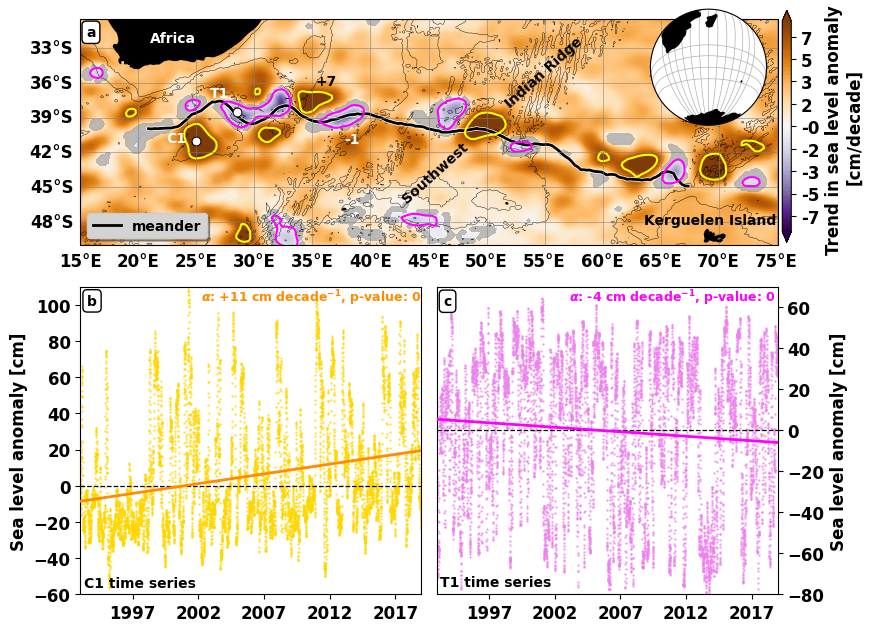

In [39]:
fig = plt.figure(figsize = (9,8))
grd = GridSpec(100,100)
extent = [14.99, 75.1, -50, -30.5]
props = dict(boxstyle='round', facecolor='w', alpha=1)
outline = mpe.withStroke(linewidth=2, foreground='w')

####################### FIGURE 1
ax = [fig.add_subplot(grd[:50,:], projection=ccrs.PlateCarree()),
      fig.add_subplot(grd[50:,:49]), fig.add_subplot(grd[50:,51:])]

ax[0].contour(bathy.xt_ocean, bathy.yt_ocean, bathy, levels=np.arange(0,8000,2000), colors='k', linewidths=.3)
cf1 = ax[0].contourf(Ln, Lt, slope_decade_SLA*1e2, np.arange(-8, 8.1, .1), cmap = 'PuOr_r', linestyles = 'solid', extend='both')
line = ax[0].plot(lon_front, lat_front_mean, color = 'w', linewidth = 3)
line = ax[0].plot(lon_front, lat_front_mean, color = 'k', linewidth = 2, label = 'meander')
ax[0].contourf(Ln, Lt, p_value_SLA, [0.05,1], cmap='gray', alpha = .5) 

## Scatter
ax[0].scatter(lon_crest_w, lat_crest_w, s = 40, color = 'w', edgecolor = 'k', zorder = 50, linewidth=.7)
ax[0].scatter(lon_trough_w, lat_trough_w, s = 40, color = 'w', edgecolor = 'k', zorder = 50, linewidth=.7)

cr_SLA = ax[0].contour(Ln, Lt, slope_decade_SLA*1e2, [-1,7], colors = ['magenta','yellow'], linestyles = 'solid')
handles_SLA, labels_SLA = cr_SLA.legend_elements()

####################################### Details
ax[0].annotate(text='C1', color='w', xy=(22.4,-41.1), xycoords='data', fontsize = 10, zorder = 300)
ax[0].annotate(text='T1', color='w', xy=(26.2,-37.2), xycoords='data', fontsize = 10, zorder = 300)
ax[0].legend(fontsize = 10, shadow = True, facecolor = 'lightgrey', loc = 'lower left')
ax[0].set_extent(extent, ccrs.PlateCarree())
ax[0].add_feature(cartopy.feature.COASTLINE)
ax[0].add_feature(cartopy.feature.LAND, facecolor='k', zorder=10)
gl = ax[0].gridlines(draw_labels = False, crs=ccrs.PlateCarree(), linewidth=0.4, color='grey')
gl.left_labels = True
gl.bottom_labels = True
gl.ylocator = mticker.FixedLocator(np.arange(-60, -30, 3))
gl.xlocator = mticker.FixedLocator(np.arange(10, 80, 5))
gl.ylabel_style = {'size': 12}
gl.xlabel_style = {'size': 12}

ax[0].annotate(text='a', color='k', xy=(15.5,-32), xycoords='data', bbox=props, fontsize = 10, zorder = 300)
ax[0].annotate(text='Africa', color='w', xy=(21,-32.5), xycoords='data', fontsize = 10, zorder = 300)
ax[0].annotate(text='Southwest', color='k', xy=(42.5,-46.3), rotation = 42, xycoords='data', fontsize = 10, zorder = 300)
ax[0].annotate(text='Indian Ridge', color='k', xy=(51.4,-38.1), rotation = 42, xycoords='data', fontsize = 10, zorder = 300)
ax[0].annotate(text='Kerguelen Island', color='k', xy=(63.6,-48.2), xycoords='data', fontsize = 10, zorder = 300)
ax[0].annotate(text='-1', color='w', xy=(37.7,-41.2), xycoords='data', fontsize = 10, zorder = 300)
ax[0].annotate(text='+7', color='k', xy=(35.3,-36.2), xycoords='data', fontsize = 10, zorder = 300)

## Colorbar
bar = plt.axes([0.905, 0.55, 0.01, 0.29])
cbar = plt.colorbar(cf1, cax = bar, format = '%.0f')  
cbar.set_label('Trend in sea level anomaly \n' +  r'[cm/decade]') 

## Figure 2 
ax[1].scatter(SLA_crest_w.time, SLA_crest_w*1e2, s = .5, color = 'gold', alpha = .7)
ax[2].scatter(SLA_crest_w.time, SLA_trough_w*1e2, s = .5, color = 'violet', alpha = .7)
ax[1].plot(SLA_crest_w.time, slope_SLA_crest_w*t_SLA + intercept_SLA_crest_w, color = 'darkorange', linewidth = 2, zorder = 10)
ax[2].plot(SLA_crest_w.time, slope_SLA_trough_w*t_SLA + intercept_SLA_trough_w, color = 'magenta', linewidth = 2, zorder = 10)
ax[1].annotate(text='b', color='k', xy=(SLA_crest_w.time[190],100), xycoords='data', bbox=props, fontsize = 10, zorder = 300)
ax[1].annotate(text=r'$\alpha$: +' + str(int(round(slope_SLA_crest_w*(365*10 + 2),0))) + r' cm decade$^{-1}$, ' +
               'p-value: ' + str(int(round(p_value_SLA_crest_w,0))), 
               color='darkorange', xy=(SLA_crest_w.time[-6150],102), xycoords='data', fontsize = 9)
ax[2].annotate(text=r'$\alpha$: ' + str(int(round(slope_SLA_trough_w*(365*10 + 2),0))) + r' cm decade$^{-1}$, ' +
               'p-value: ' + str(int(round(p_value_SLA_trough_w,0))), 
               color='magenta', xy=(SLA_crest_w.time[-5800],63), xycoords='data', fontsize = 9)
ax[2].annotate(text='c', color='k', xy=(SLA_crest_w.time[190],61), xycoords='data', bbox=props, fontsize = 10, zorder = 300)
ax[1].annotate(text='C1 time series', color='k', xy=(SLA_crest_w.time[90],-56), xycoords='data', fontsize = 10, zorder = 300)
ax[2].annotate(text='T1 time series', color='k', xy=(SLA_crest_w.time[90],-76), xycoords='data', fontsize = 10, zorder = 300)

ax[1].set_ylim(-60, 110)
ax[2].set_ylim(-80, 70)
for i in range(1, len(ax)):
    ax[i].hlines(0, SLA_crest_w.time[0], SLA_crest_w.time[-1], color = 'k', linestyle = 'dashed', linewidth = .9)
    ax[i].set_xlim(SLA_crest_w.time[0], SLA_crest_w.time[-1])
    ax[i].set_ylabel('Sea level anomaly [cm]')
    ax[i].xaxis.set_major_locator(mdates.MonthLocator(interval=60))
    ax[i].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax[2].yaxis.tick_right()
ax[2].yaxis.set_label_position("right")

# ax[2].xaxis.set_major_locator(mticker.MaxNLocator(5))
# ax[2].xaxis.autofmt_xdate()

####################### FIGURE MAP
ax = fig.add_subplot(grd[5:24,80:], projection=ccrs.NearsidePerspective(central_longitude=45, central_latitude=-45, 
                                                                        satellite_height=3000000, false_easting=0, 
                                                                        false_northing=0, globe=None))
ax.add_feature(cartopy.feature.LAND, facecolor='k', zorder=10)
gl = ax.gridlines(draw_labels = False, crs=ccrs.PlateCarree(), linewidth=0.5)
gl.ylocator = mticker.FixedLocator(np.arange(-50, -30, 5))
gl.xlocator = mticker.FixedLocator(np.arange(15, 80, 5))

plt.savefig(path_fig + 'Fig1/Fig1_v1.jpg', dpi =300, bbox_inches = 'tight')